<a href="https://colab.research.google.com/github/KeshavFTW099/R_Programming/blob/main/IDS_GYM_CaseStudy_Transformation%26Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction To Data Science: CASE STUDY ON GYM USERS DATASET - PERFORMING QUALITY TRANSFORMATIO**

In [73]:
# Reading the CSV File and printing head and tail
data <- read.csv("/content/gym_data_quality_case_study_100.csv",
                 stringsAsFactors = FALSE)
head(data)
tail(data)


,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,1,Rahul,45,50,60,1900.0
2,2,Arjun,50,55,70,2000.0
3,3,Karan,55,60,75,2100.0
4,4,Vikram,60,65,80,2200.0
5,5,Rohan,65,70,85,2300.0
6,6,Aditya,NA,75,90,2400.0


,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
95,95,Vishnu,65,70,85,7000.0
96,1,Rahul,45,50,60,1900.0
97,2,Arjun,50,55,70,2000.0
98,3,Karan,55,60,75,2100.0
99,4,Vikram,60,65,80,2200.0
100,5,Rohan,65,70,85,2300.0


In [74]:
summary(data)

   Member_ID            Name     Bench_Press_kg   Lat_Pulldown_kg 
 Min.   : 1.00   Length   :100   Min.   :-20.00   Min.   :-15.00  
 1st Qu.:20.75   N.unique : 65   1st Qu.: 55.00   1st Qu.: 60.00  
 Median :45.50   N.blank  :  0   Median : 65.00   Median : 70.00  
 Mean   :45.75   Min.nchar:  3   Mean   : 67.81   Mean   : 74.11  
 3rd Qu.:70.25   Max.nchar:  9   3rd Qu.: 80.00   3rd Qu.: 85.00  
 Max.   :95.00                   Max.   :250.00   Max.   :300.00  
                                 NAs    :4        NAs    :4       
    Squat_kg        Calorie_Intake
 Min.   :-30.00   Length   :100   
 1st Qu.: 73.75   N.unique : 15   
 Median : 85.00   N.blank  :  3   
 Mean   : 89.90   Min.nchar:  0   
 3rd Qu.: 96.25   Max.nchar: 13   
 Max.   :400.00                   
 NAs    :4                        

**THE SAME DATASET, WE WILL APPLY OPERATIONS OF THE DPLYR PACKAGE AND FIX THE ERRORS**

In [75]:
install.packages("dplyr")
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [76]:
#Replace missing numerical values with the median

data <- data %>%
  mutate(
    Bench_Press_kg = ifelse(
      is.na(Bench_Press_kg),
      median(Bench_Press_kg, na.rm = TRUE),
      Bench_Press_kg
    ),

    Lat_Pulldown_kg = ifelse(
      is.na(Lat_Pulldown_kg),
      median(Lat_Pulldown_kg, na.rm = TRUE),
      Lat_Pulldown_kg
    ),

    Squat_kg = ifelse(
      is.na(Squat_kg),
      median(Squat_kg, na.rm = TRUE),
      Squat_kg
    )
  )

In [77]:
# fixing missing calorie intake
data <- data %>%
  mutate(
    Calorie_Intake = ifelse(
      is.na(Calorie_Intake),
      "2300.0",
      Calorie_Intake
    )
  )

In [78]:
colSums(is.na(data))

Member_ID            Name  Bench_Press_kg Lat_Pulldown_kg        Squat_kg 
              0               0               0               0               0 
 Calorie_Intake 
              0

**Objective 2: De-duplication with dplyr**

In [79]:
library(dplyr)

data %>%
  filter(duplicated(.))
data %>%
  summarise(Duplicate_Rows = sum(duplicated(.)))

Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,Rahul,45,50,60,1900.0
2,Arjun,50,55,70,2000.0
3,Karan,55,60,75,2100.0
4,Vikram,60,65,80,2200.0
5,Rohan,65,70,85,2300.0


Duplicate_Rows
<int>
5


In [80]:
#Remove duplicates and verify that they are removed
data <- data %>%
  distinct()

data %>%
  summarise(Duplicate_Rows = sum(duplicated(.)))

Duplicate_Rows
<int>
0


**Objective 3: Inconsistent Data Values — Solution using dplyr**

In [81]:
#replacing first
data <- data %>%
  mutate(
    Bench_Press_kg = ifelse(Bench_Press_kg <= 0, NA, Bench_Press_kg),
    Lat_Pulldown_kg = ifelse(Lat_Pulldown_kg <= 0, NA, Lat_Pulldown_kg),
    Squat_kg = ifelse(Squat_kg <= 0, NA, Squat_kg)
  )

In [82]:
#check replaced
data %>%
  summarise(
    Invalid_Bench = sum(Bench_Press_kg <= 0, na.rm = TRUE),
    Invalid_Lat = sum(Lat_Pulldown_kg <= 0, na.rm = TRUE),
    Invalid_Squat = sum(Squat_kg <= 0, na.rm = TRUE)
  )
  summary(data[, c("Bench_Press_kg",
                 "Lat_Pulldown_kg",
                 "Squat_kg")]) #summarising values

Invalid_Bench,Invalid_Lat,Invalid_Squat
<int>,<int>,<int>
0,0,0


 Bench_Press_kg   Lat_Pulldown_kg     Squat_kg    
 Min.   : 45.00   Min.   : 50.00   Min.   : 60.0  
 1st Qu.: 55.00   1st Qu.: 60.00   1st Qu.: 75.0  
 Median : 65.00   Median : 70.00   Median : 85.0  
 Mean   : 70.05   Mean   : 76.45   Mean   : 92.8  
 3rd Qu.: 80.00   3rd Qu.: 85.00   3rd Qu.:100.0  
 Max.   :250.00   Max.   :300.00   Max.   :400.0  
 NAs    :2        NAs    :2        NAs    :2      

**Objective 4: Detect Possible Outliers & Plot them**

In [83]:
Q1 <- quantile(data$Bench_Press_kg, 0.25, na.rm = TRUE)
Q3 <- quantile(data$Bench_Press_kg, 0.75, na.rm = TRUE)

IQR_value <- Q3 - Q1

lower <- Q1 - 1.5 * IQR_value
upper <- Q3 + 1.5 * IQR_value

lower
upper #Calculate IQR limits

25% 
17.5

75% 
117.5

In [84]:
data <- data %>%
  filter(Bench_Press_kg >= lower &
         Bench_Press_kg <= upper)

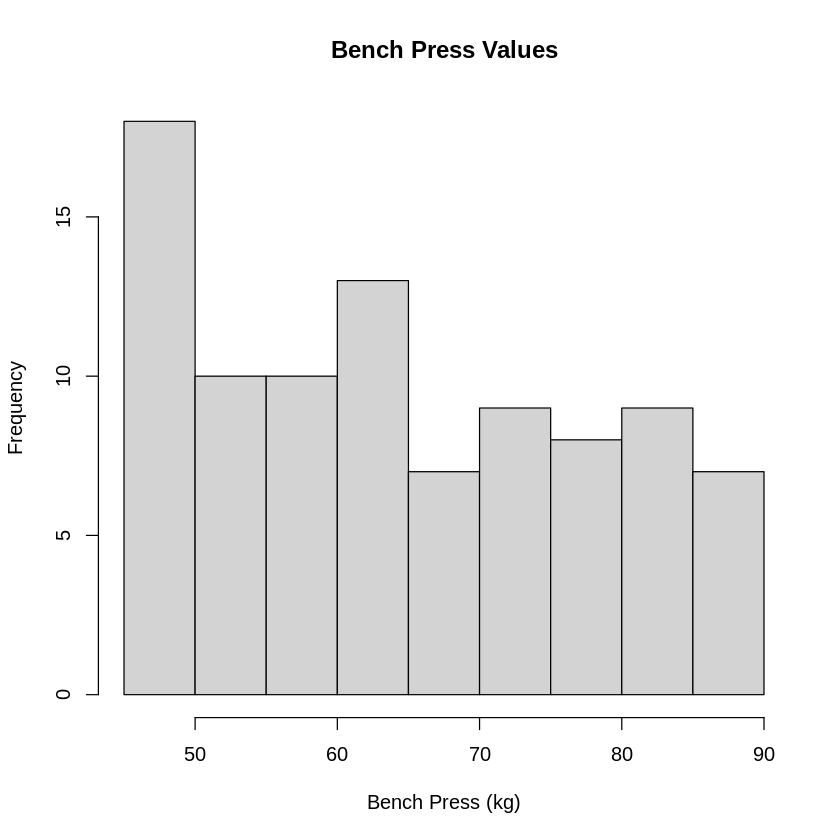

In [85]:
hist(data$Bench_Press_kg,
     main = "Bench Press Values",
     xlab = "Bench Press (kg)",
     ylab = "Frequency",
     breaks = 10)

**Objective 5: Examine the Distribution of Numerical Variables & Normalise and plot**

In [86]:
#Clean Bench Press and Lat Pulldown USING NORMALISATION APPROACH
data <- data %>%
  mutate(
    Bench_Normalized = (Bench_Press_kg - min(Bench_Press_kg, na.rm = TRUE)) /
                       (max(Bench_Press_kg, na.rm = TRUE) -
                        min(Bench_Press_kg, na.rm = TRUE)),

    Lat_Normalized = (Lat_Pulldown_kg - min(Lat_Pulldown_kg, na.rm = TRUE)) /
                     (max(Lat_Pulldown_kg, na.rm = TRUE) -
                      min(Lat_Pulldown_kg, na.rm = TRUE))
  )

The original measurements are in kg, so Bench Press and Lat Pulldown have different ranges. Min-max normalization converts both to:

0 = minimum value
1 = maximum value

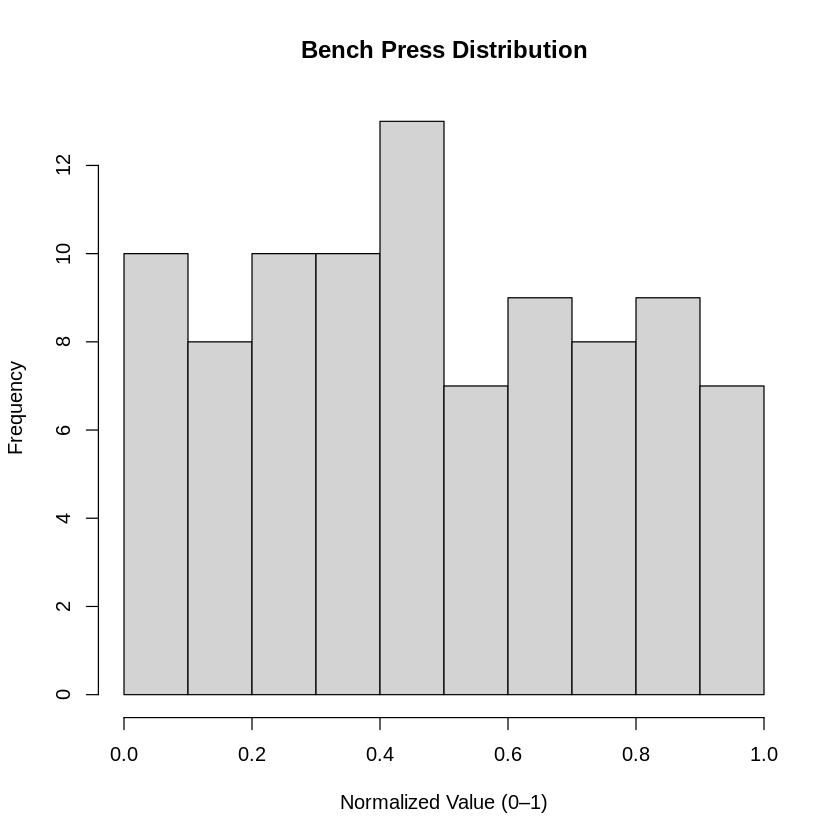

In [87]:
hist(data$Bench_Normalized,
     main = "Bench Press Distribution",
     xlab = "Normalized Value (0–1)",
     ylab = "Frequency",
     breaks = 8)

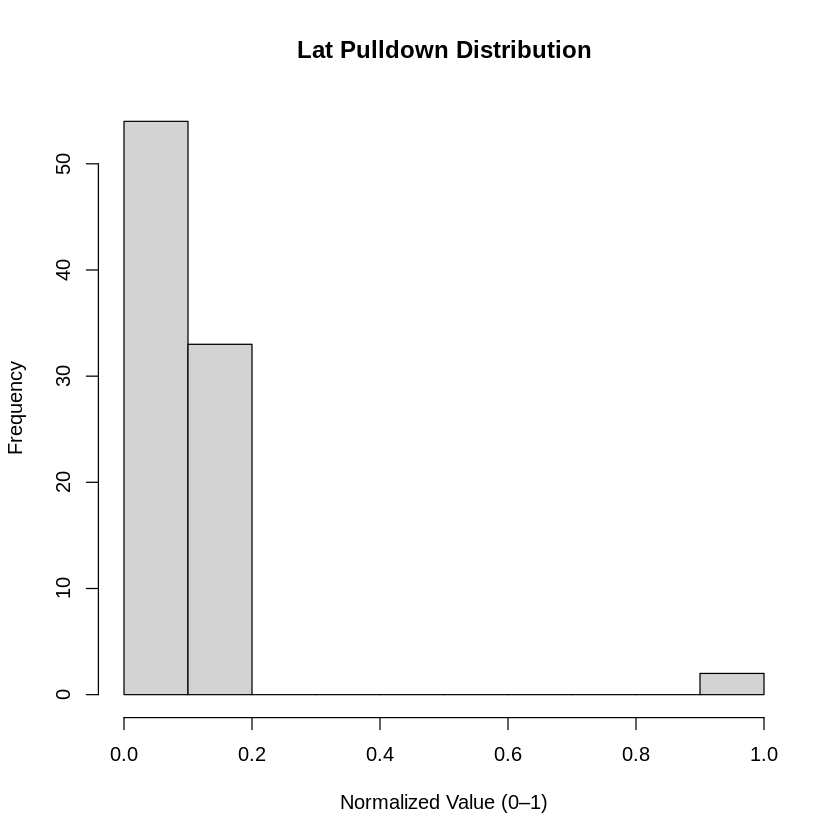

In [88]:
hist(data$Lat_Normalized,
     main = "Lat Pulldown Distribution",
     xlab = "Normalized Value (0–1)",
     ylab = "Frequency",
     breaks = 8)

**Objective 6: Inappropriate Data Types — Solution using DPLYR**

In [89]:
data <- data %>%
  mutate(
    Calorie_Intake = gsub("[^0-9.]", "", Calorie_Intake)
  ) #REMOVE TEXT FROM CALORIES
  data <- data %>%
  mutate(
    Calorie_Intake = as.numeric(Calorie_Intake)
  ) #CONVERT INTO NUMERIC

  #VERIFYING
  class(data$Calorie_Intake)

[1] "numeric"

In [90]:
sapply(data, class)

Member_ID             Name   Bench_Press_kg  Lat_Pulldown_kg 
       "integer"      "character"        "numeric"        "numeric" 
        Squat_kg   Calorie_Intake Bench_Normalized   Lat_Normalized 
       "numeric"        "numeric"        "numeric"        "numeric"

**Objective 7: Visually showing solved problems**

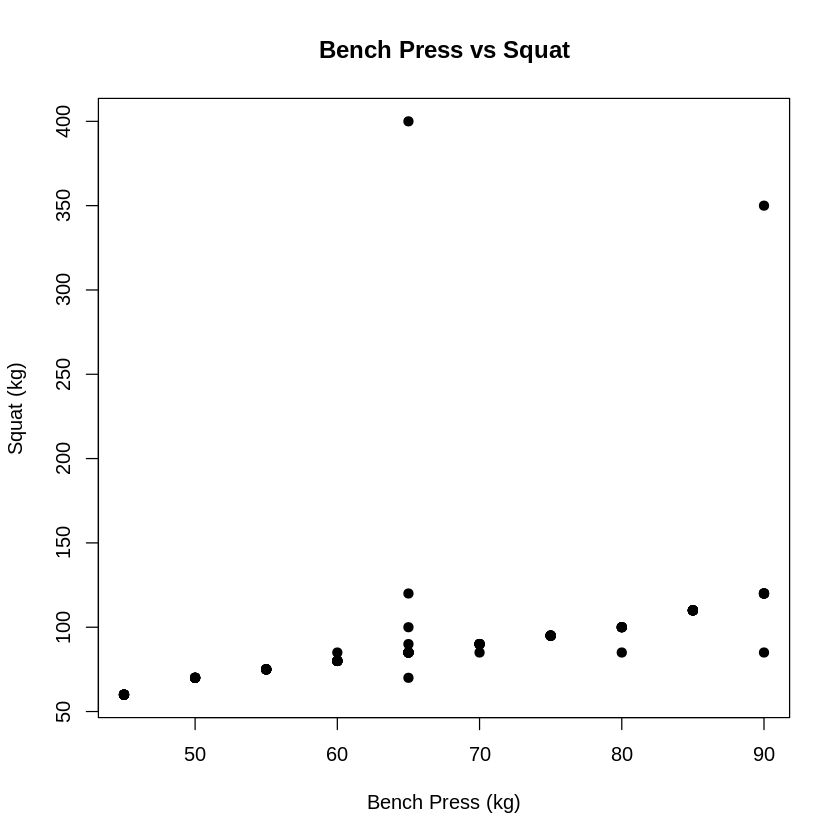

In [91]:
plot(data$Bench_Press_kg,
     data$Squat_kg,
     main = "Bench Press vs Squat",
     xlab = "Bench Press (kg)",
     ylab = "Squat (kg)",
     pch = 19)

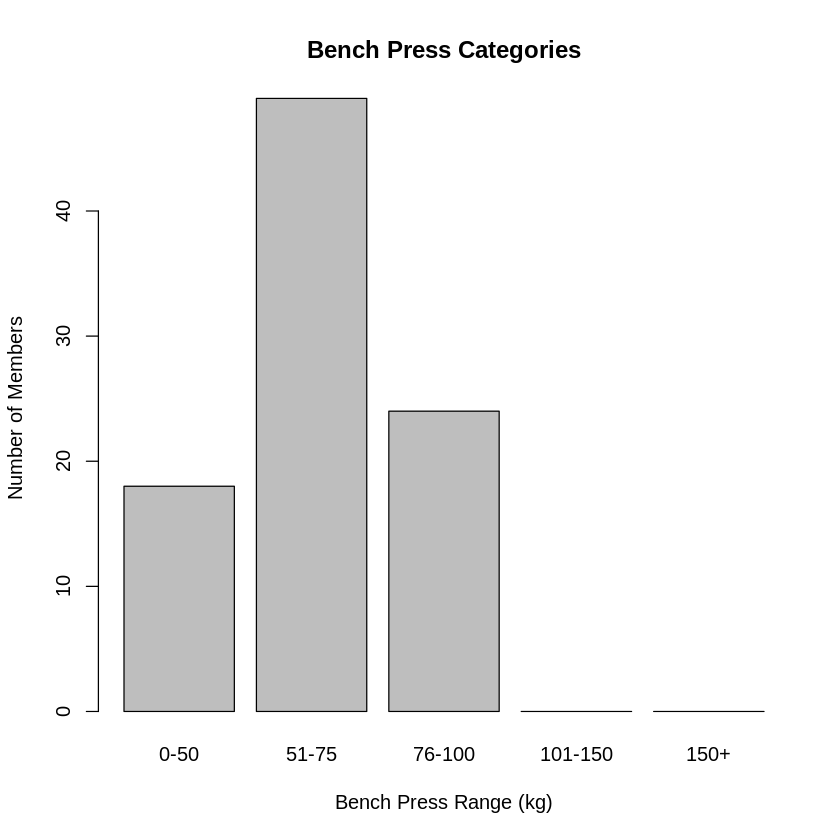

In [92]:
bench_groups <- cut(data$Bench_Press_kg,
                    breaks = c(0, 50, 75, 100, 150, Inf),
                    labels = c("0-50", "51-75", "76-100", "101-150", "150+"))

barplot(table(bench_groups),
        main = "Bench Press Categories",
        xlab = "Bench Press Range (kg)",
        ylab = "Number of Members")

**FINAL SUMMARY OF CLEANED DATA**

In [93]:

glimpse(data)

Rows: 91
Columns: 8
$ Member_ID        <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17…
$ Name             <chr> "Rahul", "Arjun", "Karan", "Vikram", "Rohan", "Aditya…
$ Bench_Press_kg   <dbl> 45, 50, 55, 60, 65, 65, 75, 80, 85, 90, 45, 50, 55, 6…
$ Lat_Pulldown_kg  <dbl> 50, 55, 60, 65, 70, 75, 80, 85, 90, 70, 50, 55, 60, 6…
$ Squat_kg         <dbl> 60, 70, 75, 80, 85, 90, 95, 100, 110, 120, 60, 70, 75…
$ Calorie_Intake   <dbl> 1900, 2000, 2100, 2200, 2300, 2400, 2500, NA, 2700, 2…
$ Bench_Normalized <dbl> 0.0000000, 0.1111111, 0.2222222, 0.3333333, 0.4444444…
$ Lat_Normalized   <dbl> 0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16,…


In [94]:
colSums(is.na(data))

sum(duplicated(data))

Member_ID             Name   Bench_Press_kg  Lat_Pulldown_kg 
               0                0                0                2 
        Squat_kg   Calorie_Intake Bench_Normalized   Lat_Normalized 
               2                3                0                2

[1] 0